# SF Data Cleaning Notebook - Initial (Ibrahim)

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

## The `load_data()` function

- Loads in the sf data and the [geojson file](https://data.sfgov.org/Geographic-Locations-and-Boundaries/Bay-Area-County-Polygons/wamw-vt4s/data_preview)
- Converts the sf data to have valid coordinates
- Returns both files

In [ ]:
def load_data(sf_path, geo_path):
    
    # Loading in files
    df = pd.read_csv(sf_path)
    sf = gpd.read_file(geo_path)
    
    # Converting to geopandas df (coordinates go in the correct format)
    gdf = gpd.GeoDataFrame(df, geometry = gpd.points_from_xy(df.lng, df.lat), crs = 'EPSG:4326')
    
    # For debugging: Make sure the points have the same coordinate system
    print("Shapefile CRS:", sf.crs)
    print("Points CRS:", gdf.crs)
    
    return sf, gdf

# Paths need changing based on your setup
sf_path = 'C:/Users/mehre/OneDrive/Documents/sds357_project/ca_san_francisco_2020_04_01.csv'
geo_path = "C:/Users/mehre/OneDrive/Documents/sds357_project/Bay_Area_County_Polygons_20260206.geojson"
sf, gdf = load_data(sf_path, geo_path)
gdf.head()

C:\Users\mehre\AppData\Local\Temp\ipykernel_8848\4224946934.py:4: DtypeWarning: Columns (0: district) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(sf_path)


Shapefile CRS: EPSG:4326
Points CRS: EPSG:4326


,raw_row_number,date,time,location,lat,lng,district,subject_age,subject_race,subject_sex,...,warning_issued,outcome,contraband_found,search_conducted,search_vehicle,search_basis,reason_for_stop,raw_search_vehicle_description,raw_result_of_contact_description,geometry
0,869921,2014-08-01,00:01:00,MASONIC AV & FELL ST,37.773004,-122.445873,NaN,NaN,asian/pacific islander,female,...,True,warning,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Warning,POINT (-122.44587 37.773)
1,869922,2014-08-01,00:01:00,GEARY&10TH AV,37.780898,-122.468586,NaN,NaN,black,male,...,False,citation,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Citation,POINT (-122.46859 37.7809)
2,869923,2014-08-01,00:15:00,SUTTER N OCTAVIA ST,37.786919,-122.426718,NaN,NaN,hispanic,male,...,False,citation,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Citation,POINT (-122.42672 37.78692)
3,869924,2014-08-01,00:18:00,3RD ST & DAVIDSON,37.746380,-122.392005,NaN,NaN,hispanic,male,...,True,warning,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Warning,POINT (-122.392 37.74638)
4,869925,2014-08-01,00:19:00,DIVISADERO ST. & BUSH ST.,37.786348,-122.440003,NaN,NaN,white,male,...,False,citation,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Citation,POINT (-122.44 37.78635)


## Initial Plot (Before preprocessing)

We can see that there are many incorrect coordinates that don't line up with the boundary of SF.

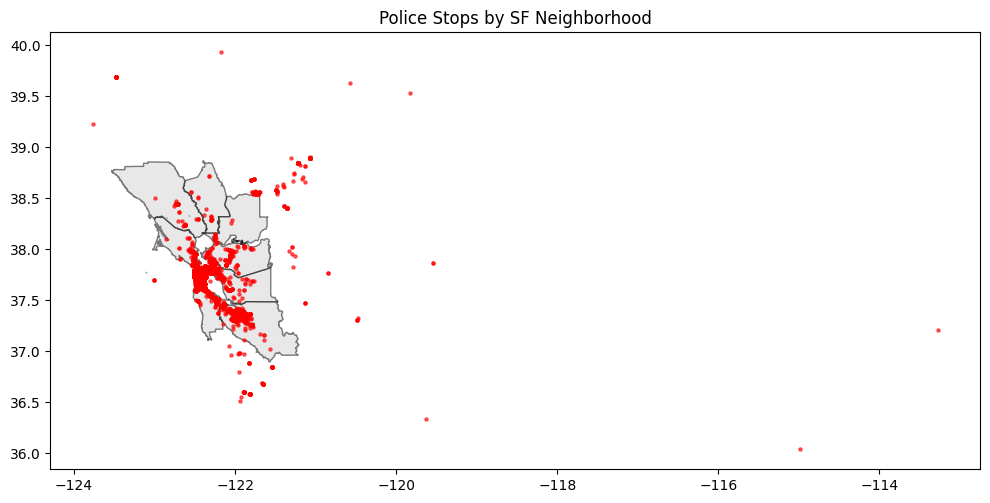

In [3]:
# Plot
fig, ax = plt.subplots(figsize=(12, 10))
sf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
gdf.plot(ax=ax, color='red', markersize=5, alpha=0.6)
plt.title("Police Stops by SF Neighborhood")
plt.show()

We can see here that the bounds of the points don't match with the geojson file

In [4]:
# Check a few coordinates
print(gdf.head()[['geometry']])
print("\nBounds of shapefile:", sf.total_bounds)
print("Bounds of points:", gdf.total_bounds)

                      geometry
0    POINT (-122.44587 37.773)
1   POINT (-122.46859 37.7809)
2  POINT (-122.42672 37.78692)
3    POINT (-122.392 37.74638)
4     POINT (-122.44 37.78635)

Bounds of shapefile: [-123.53367    36.894155 -121.208178   38.864245]
Bounds of points: [-123.7674293   36.038676  -113.2681513   39.929646 ]


In [5]:
print("Total points:", len(gdf))
print("Points outside shapefile bounds:", 
      ((gdf.geometry.x < -123.6) | (gdf.geometry.x > -121.0) |
       (gdf.geometry.y < 36.8) | (gdf.geometry.y > 39.0)).sum())

Total points: 905070
Points outside shapefile bounds: 97


## The `fix_coordinates()` function

- Takes in the `gdf` and the `sf`
- Calculates the boundds of the `sf`
- Filters out points in the `gdf` that don't fit in the `sf`
- Returns a `gdf_clean`

There needs to be more research in this section. There are still some points that don't line up (not sure why). Maybe look into the data set if they have anything in common and if they will be filtered out when we narrow down our data set to see the impact of Vision Zero.

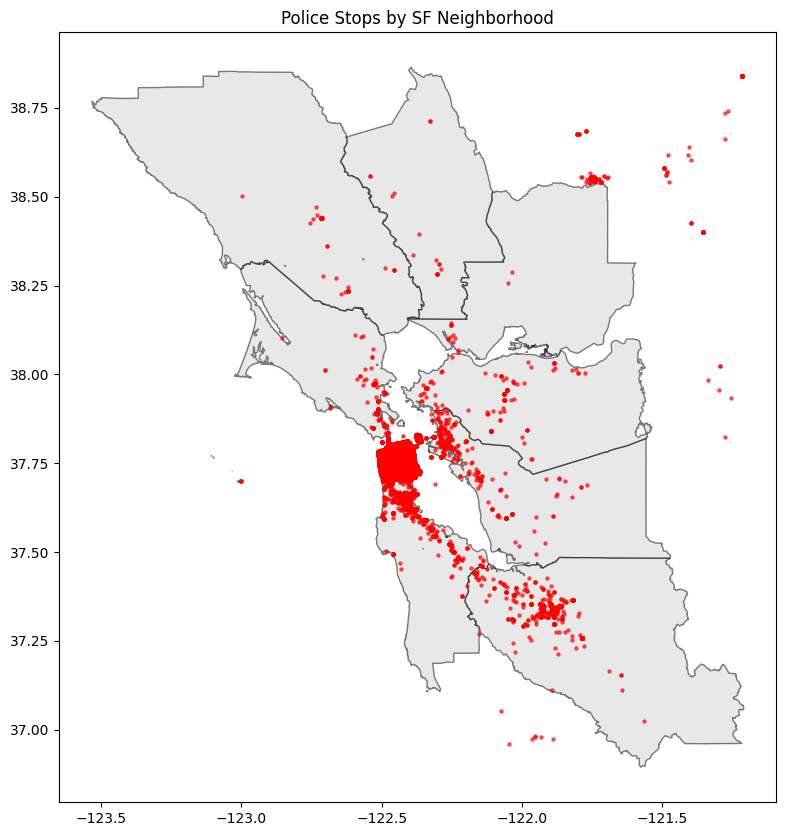

In [6]:
def fix_coordinates(gdf, sf):
    
    # Get sf (geojson bounds) and filter points
    minx, miny, maxx, maxy = sf.total_bounds
    gdf_clean = gdf[
    (gdf.geometry.x >= minx) & 
    (gdf.geometry.x <= maxx) &
    (gdf.geometry.y >= miny) & 
    (gdf.geometry.y <= maxy)
]
    
    return gdf_clean

gdf_clean = fix_coordinates(gdf, sf)

# Now plot with clean data
fig, ax = plt.subplots(figsize=(12, 10))
sf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
gdf_clean.plot(ax=ax, color='red', markersize=5, alpha=0.6)
plt.title("Police Stops by SF Neighborhood")
plt.show()   